# Imports

In [ ]:
import numpy as np
import pandas as pd

from pyFiberPhotometry import SimulatedPhotometryGenerator
from pyFiberPhotometry import PhotometryExperiment, PhotometryData

# Build Simulated data

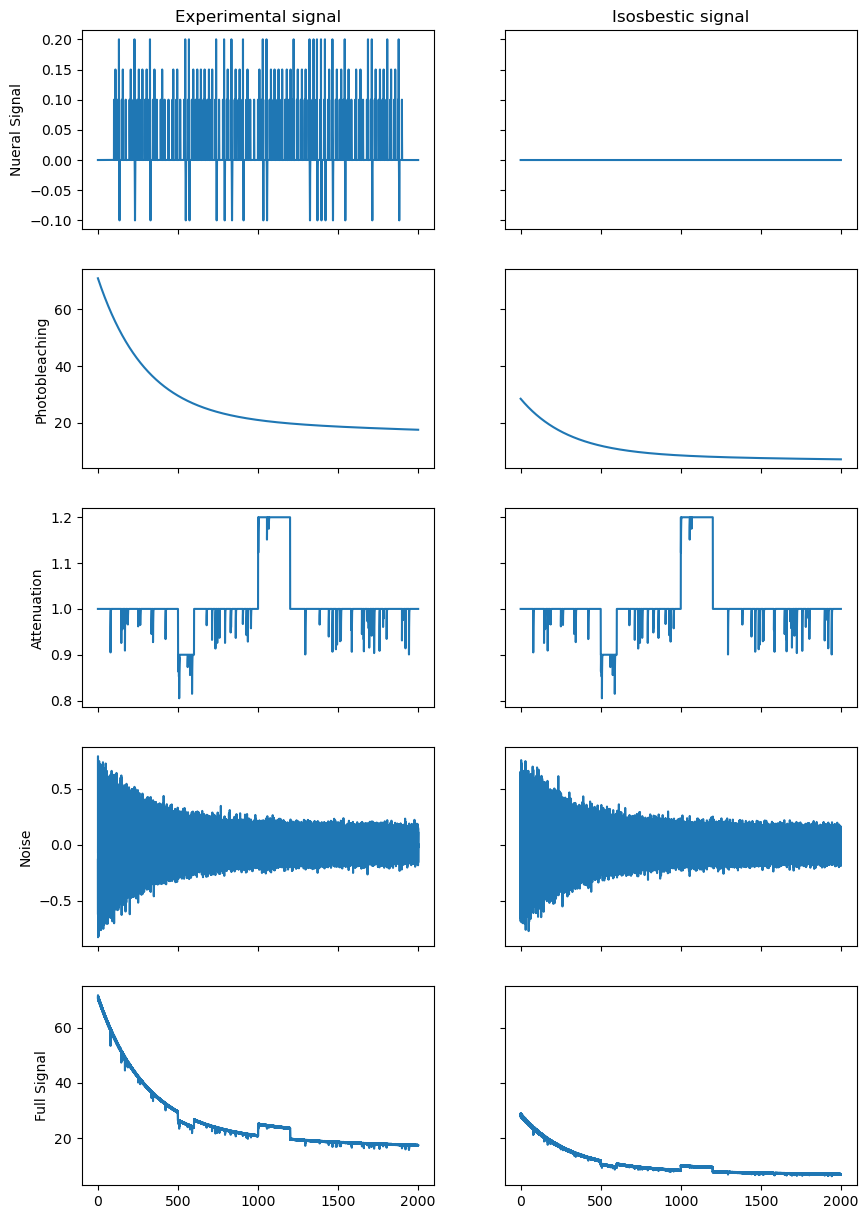

In [2]:
T_sec = 2000
fs = 1000
N = T_sec * fs

bleach_params = dict(a1=50, a2=20, tau1=300, tau2=10000, b0=1)

artifact_mask = np.ones(shape=N)
unit_idx = N // 20
artifact_mask[10*unit_idx : 12*unit_idx] += 0.2
artifact_mask[5*unit_idx : 6*unit_idx] -= 0.1

sim = SimulatedPhotometryGenerator(
    T_sec=T_sec,
    fs=fs,
    n_events=75,
    A_neural=0.1,
    buffer_sec=100,
    tau_p_sec=0.2,
    bleach_params=bleach_params,
    bleach_iso_scale=0.4,
    dependent_sigma_exp=2e-1,
    dependent_sigma_iso=2e-1,
    independent_sigma_exp=5e-5,
    independent_sigma_iso=5e-5,
    seed=43546,
    event_dur_sec=2,
    artifact_depth_range=(0.02, 0.10),
    artifact_mask=artifact_mask,
)

sim.add_event(
    relative_to='event',
    time_range=(3, 8),
    overall_prob=0.8,
    choices=['lever1', 'lever2'],
    choice_probs=[0.6, 0.4],
    peak_specs={
        'lever1' : {'amplitude':0.15, 'event_dur_sec':4, 'tau_p_sec':3, 'shape_k':5},
        'lever2' : {'amplitude':0.2, 'event_dur_sec':2, 'tau_p_sec':0.1, 'shape_k':4},
    }
)

sim.add_event(
    relative_to='lever2',
    time_range=(0, 1),
    overall_prob=0.8,
    choices=['loud_noise'],
    choice_probs=[1.0],
    peak_specs={
        'loud_noise' : {'amplitude':-0.1, 'event_dur_sec':5, 'tau_p_sec':3, 'shape_k':5},
    }
)

sim.plot_layers()

# Exercises

## Task 1
1. Preprocess the signal with dF/F, IRLS, and a cutoff frequency of 5 Hz.
2. Then extract the trial data and set ``tr = exp.trial_data``

In [3]:
# setup
exp = sim.to_PhotometryExperiment()

# solve


## Task 2
1. Label the trials in tr.obs according to the following:
    - If 'lever1' and 'lever2' are missing, label = 'no_response'
    - If 'lever1', label = 'type1'
    - If 'lever2' and 'loud_noise' is missing, label = 'type2'
    - If 'lever2' and 'loud_noise', label = 'type3'

Hint: remeber an NaN value represents a missing event.

In [4]:
# solve


## Task 3
1. Filter out 'NoResponse' trials
2. Average trials of the same type
3. Plot the trials on the same graph with error bars and labels

In [5]:
# solve
